# 🥔 Potato Disease — Custom CNN v5 (Final Version)
### 80/10/10 Split | Temperature Scaling | TTA | Mixed Precision | Top-2 Predictions
**Just run all cells top to bottom.**

**Changes from v3 (architecture unchanged):**
- ✅ Temperature scaling (T=1.5) — calibrates overconfident probabilities for real-world images
- ✅ Test-time augmentation (TTA, 5 passes) — more stable & accurate predictions
- ✅ Mixed precision inference — faster GPU inference with autocast
- ✅ Top-2 predictions — shows 2nd best class when model is uncertain between diseases
- ✅ Optimal threshold saved into checkpoint — no more hardcoded 0.80
- ✅ All v3 fixes retained: 80/10/10 split, Healthy boost 1.5×, num_workers=0

In [1]:
# ── CELL 1: GPU Check ─────────────────────────────────────────────────────────
import torch
torch.backends.cudnn.benchmark = True  # faster convolutions on fixed input size
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import os, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
print('✅ Imports done!')

✅ Imports done!


In [3]:
# ── CELL 3: Config ────────────────────────────────────────────────────────────
DATA_PATH       = './PlantVillage/train'   # ⚠️ Merged folder (train + old valid combined)
MODEL_SAVE_PATH = './models_scratch'

IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_CLASSES = 3
EPOCHS      = 80
LR          = 1e-3
WEIGHT_DECAY= 1e-4

# 80 / 10 / 10 split
TRAIN_SPLIT = 0.80
VAL_SPLIT   = 0.10

# v5 additions
CONFIDENCE_THRESHOLD = 0.80   # updated after Cell 19 threshold analysis
TEMPERATURE          = 1.5    # temperature scaling — softens overconfident predictions
TTA_STEPS            = 5      # test-time augmentation passes

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print('✅ Config ready!')
print(f'   Data path   : {DATA_PATH}')
print(f'   Split       : {int(TRAIN_SPLIT*100)}/{int(VAL_SPLIT*100)}/{int((1-TRAIN_SPLIT-VAL_SPLIT)*100)}')
print(f'   Threshold   : {int(CONFIDENCE_THRESHOLD*100)}%')
print(f'   Temperature : {TEMPERATURE}')
print(f'   TTA steps   : {TTA_STEPS}')

✅ Config ready!
   Data path   : ./PlantVillage/train
   Split       : 80/10/9
   Threshold   : 80%
   Temperature : 1.5
   TTA steps   : 5


In [4]:
# ── CELL 4: Transforms ────────────────────────────────────────────────────────
# Each dataset gets its OWN transform object — no shared references
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(40),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.08),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08))
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
print('✅ Transforms ready!')

✅ Transforms ready!


In [5]:
# ── CELL 5: Load Datasets — 80/10/10 Stratified Split ────────────────────────
from PIL import Image as PILImage  # explicit import at cell level

class SubsetWithTransform(torch.utils.data.Dataset):
    """Wraps an ImageFolder with per-split transforms, no leakage."""
    def __init__(self, samples, transform):
        # samples = list of (img_path, label) tuples
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = PILImage.open(img_path).convert('RGB')
        return self.transform(img), label

# Load full dataset just to get samples list + class names
full_ds     = datasets.ImageFolder(DATA_PATH)
CLASS_NAMES = full_ds.classes
all_samples = full_ds.samples          # list of (path, label)
all_labels  = [s[1] for s in all_samples]

# Stratified 80/10/10 split per class
train_samples, val_samples, test_samples = [], [], []
train_labels_list = []   # keep for sampler in Cell 6

for cls_id in range(NUM_CLASSES):
    cls_samples = [(p, l) for p, l in all_samples if l == cls_id]
    np.random.shuffle(cls_samples)
    n       = len(cls_samples)
    n_train = int(n * TRAIN_SPLIT)
    n_val   = int(n * VAL_SPLIT)
    train_samples.extend(cls_samples[:n_train])
    val_samples.extend(cls_samples[n_train:n_train + n_val])
    test_samples.extend(cls_samples[n_train + n_val:])
    train_labels_list.extend([cls_id] * n_train)

train_ds = SubsetWithTransform(train_samples, train_transform)
val_ds   = SubsetWithTransform(val_samples,   eval_transform)
test_ds  = SubsetWithTransform(test_samples,  eval_transform)

total = len(all_samples)
print(f'Classes   : {CLASS_NAMES}')
print(f'Total     : {total}')
print(f'Train     : {len(train_ds)}  ({len(train_ds)/total*100:.1f}%)')
print(f'Val       : {len(val_ds)}   ({len(val_ds)/total*100:.1f}%)')
print(f'Test      : {len(test_ds)}   ({len(test_ds)/total*100:.1f}%)')
print()
print('Per-class distribution in train:')
from collections import Counter
tc = Counter(l for _, l in train_samples)
for cls_id, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {tc[cls_id]}')

Classes   : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Total     : 9280
Train     : 7423  (80.0%)
Val       : 927   (10.0%)
Test      : 930   (10.0%)

Per-class distribution in train:
  Potato___Early_blight: 2739
  Potato___Late_blight: 2739
  Potato___healthy: 1945


In [6]:
# ── CELL 6: Dataloaders + Class Balance (Boosted Healthy Weight) ──────────────
HEALTHY_BOOST = 1.5

# Balanced class weights from train split
train_labels_arr = np.array(train_labels_list)
unique_classes   = np.unique(train_labels_arr)
class_weights    = compute_class_weight('balanced', classes=unique_classes, y=train_labels_arr)

# Boost Healthy weight — find index dynamically
healthy_cls_name = [n for n in CLASS_NAMES if 'healthy' in n.lower()][0]
healthy_idx      = CLASS_NAMES.index(healthy_cls_name)
class_weights[healthy_idx] *= HEALTHY_BOOST

print('Class weights for loss (after Healthy boost):')
for name, w in zip(CLASS_NAMES, class_weights):
    tag = '  ← boosted' if name == healthy_cls_name else ''
    print(f'  {name}: {w:.3f}{tag}')

# Sampler uses base balanced weights (not boosted) — sampler balances batches,
# loss handles the extra Healthy penalty
base_weights   = compute_class_weight('balanced', classes=unique_classes, y=train_labels_arr)
sample_weights = [float(base_weights[l]) for l in train_labels_arr]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# num_workers=0 avoids DataLoader multiprocessing deadlock on many setups
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')
print('✅ DataLoaders ready (num_workers=0)')

Class weights for loss (after Healthy boost):
  Potato___Early_blight: 0.903
  Potato___Late_blight: 0.903
  Potato___healthy: 1.908  ← boosted

Train batches: 232 | Val: 29 | Test: 30
✅ DataLoaders ready (num_workers=0)


In [7]:
# ── CELL 7: CNN Architecture ──────────────────────────────────────────────────
#
# PotatoCNNFinal — 6 blocks, residual skip connections
#
#   Block1: Conv(3→32)    + BN + ReLU x2 + Pool        [224→112]
#   Block2: Conv(32→64)   + BN + ReLU x2 + Pool        [112→56]
#   Block3: Conv(64→128)  + Skip + BN + ReLU x2 + Pool [56→28]
#   Block4: Conv(128→256) + Skip + BN + ReLU x2 + Pool [28→14]
#   Block5: Conv(256→512) + Skip + BN + ReLU x2 + Pool [14→7]
#   Block6: Conv(512→512) + BN + ReLU x2 + Pool        [7→3]
#   GAP → FC(1024) → BN → ReLU → Drop(0.4) → FC(512) → Drop(0.3) → FC(3)

class ConvBNRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)


class Block(nn.Module):
    """Double conv + optional residual skip + pool"""
    def __init__(self, in_ch, out_ch, dropout=0.0, use_skip=False):
        super().__init__()
        self.conv1   = ConvBNRelu(in_ch, out_ch)
        self.conv2   = ConvBNRelu(out_ch, out_ch)
        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.use_skip = use_skip
        if use_skip:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch)
            ) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        if self.use_skip:
            out = out + self.skip(x)
            out = F.relu(out, inplace=True)
        out = self.pool(out)
        out = self.dropout(out)
        return out


class PotatoCNNFinal(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.b1 = Block(3,   32,  dropout=0.0,  use_skip=False)
        self.b2 = Block(32,  64,  dropout=0.0,  use_skip=False)
        self.b3 = Block(64,  128, dropout=0.1,  use_skip=True)
        self.b4 = Block(128, 256, dropout=0.1,  use_skip=True)
        self.b5 = Block(256, 512, dropout=0.15, use_skip=True)
        self.b6 = Block(512, 512, dropout=0.15, use_skip=False)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.b1(x); x = self.b2(x)
        x = self.b3(x); x = self.b4(x)
        x = self.b5(x); x = self.b6(x)
        x = self.gap(x)
        return self.classifier(x)


model = PotatoCNNFinal(NUM_CLASSES).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Model    : PotatoCNNFinal v2 (Scratch)')
print(f'Params   : {total:,}')
print(f'Device   : {DEVICE}')

# Sanity check
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
print(f'Output   : {model(dummy).shape}  ✅')

Model    : PotatoCNNFinal v2 (Scratch)
Params   : 10,662,371
Device   : cuda
Output   : torch.Size([2, 3])  ✅


In [8]:
# ── CELL 8: Loss + Optimizer + Scheduler ─────────────────────────────────────
# NO label smoothing — keeps predictions sharp and confident
# class_weights already has Healthy boosted 1.5× from Cell 6
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
criterion      = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.2,
    div_factor=10,
    final_div_factor=1000
)

print('✅ Loss      : CrossEntropyLoss (weighted, Healthy boosted 1.5×, NO label smoothing)')
print('✅ Optimizer : AdamW')
print('✅ Scheduler : OneCycleLR')
print(f'✅ Epochs    : {EPOCHS}')

✅ Loss      : CrossEntropyLoss (weighted, Healthy boosted 1.5×, NO label smoothing)
✅ Optimizer : AdamW
✅ Scheduler : OneCycleLR
✅ Epochs    : 80


In [9]:
# ── CELL 9: Training Loop ─────────────────────────────────────────────────────
# Best model saved on val LOSS (more stable than val acc)
best_wts      = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
best_val_acc  = 0.0
no_improve    = 0
patience      = 20
history       = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print('🚀 Training started...\n')

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    t_loss, t_correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(inputs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        t_loss    += loss.item() * inputs.size(0)
        t_correct += (out.argmax(1) == labels).sum().item()

    # ── Validate ──
    model.eval()
    v_loss, v_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            out   = model(inputs)
            loss  = criterion(out, labels)
            v_loss    += loss.item() * inputs.size(0)
            v_correct += (out.argmax(1) == labels).sum().item()

    tl = t_loss / len(train_loader.dataset)
    ta = t_correct / len(train_loader.dataset)
    vl = v_loss / len(val_ds)
    va = v_correct / len(val_ds)

    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)

    # Save best on val loss (more stable signal than val acc)
    marker = ''
    if vl < best_val_loss:
        best_val_loss = vl
        best_val_acc  = va
        best_wts      = copy.deepcopy(model.state_dict())
        no_improve    = 0
        marker        = '  ✅ Best!'
    else:
        no_improve += 1

    print(f'Ep[{epoch+1:02d}/{EPOCHS}] '
          f'T_Loss:{tl:.4f} T_Acc:{ta:.4f} | '
          f'V_Loss:{vl:.4f} V_Acc:{va:.4f}{marker}')

    if no_improve >= patience:
        print(f'\nEarly stop at epoch {epoch+1}')
        break

model.load_state_dict(best_wts)
print(f'\n🏆 Best Val Loss : {best_val_loss:.4f}')
print(f'🏆 Best Val Acc  : {best_val_acc*100:.2f}%')

🚀 Training started...

Ep[01/80] T_Loss:0.8674 T_Acc:0.5760 | V_Loss:0.3845 V_Acc:0.8123  ✅ Best!
Ep[02/80] T_Loss:0.3810 T_Acc:0.8297 | V_Loss:0.1350 V_Acc:0.9536  ✅ Best!
Ep[03/80] T_Loss:0.2215 T_Acc:0.9079 | V_Loss:0.0439 V_Acc:0.9817  ✅ Best!
Ep[04/80] T_Loss:0.1869 T_Acc:0.9274 | V_Loss:0.0543 V_Acc:0.9827
Ep[05/80] T_Loss:0.1548 T_Acc:0.9414 | V_Loss:0.0711 V_Acc:0.9795
Ep[06/80] T_Loss:0.1507 T_Acc:0.9454 | V_Loss:0.0412 V_Acc:0.9860  ✅ Best!
Ep[07/80] T_Loss:0.1453 T_Acc:0.9454 | V_Loss:0.0492 V_Acc:0.9871
Ep[08/80] T_Loss:0.1399 T_Acc:0.9519 | V_Loss:0.0524 V_Acc:0.9838
Ep[09/80] T_Loss:0.1363 T_Acc:0.9520 | V_Loss:0.0382 V_Acc:0.9892  ✅ Best!
Ep[10/80] T_Loss:0.1358 T_Acc:0.9523 | V_Loss:0.0135 V_Acc:0.9946  ✅ Best!
Ep[11/80] T_Loss:0.1078 T_Acc:0.9592 | V_Loss:0.1370 V_Acc:0.9666
Ep[12/80] T_Loss:0.1142 T_Acc:0.9588 | V_Loss:0.0217 V_Acc:0.9892
Ep[13/80] T_Loss:0.1125 T_Acc:0.9590 | V_Loss:0.0232 V_Acc:0.9935
Ep[14/80] T_Loss:0.1194 T_Acc:0.9615 | V_Loss:0.0200 V_Acc:0.9935

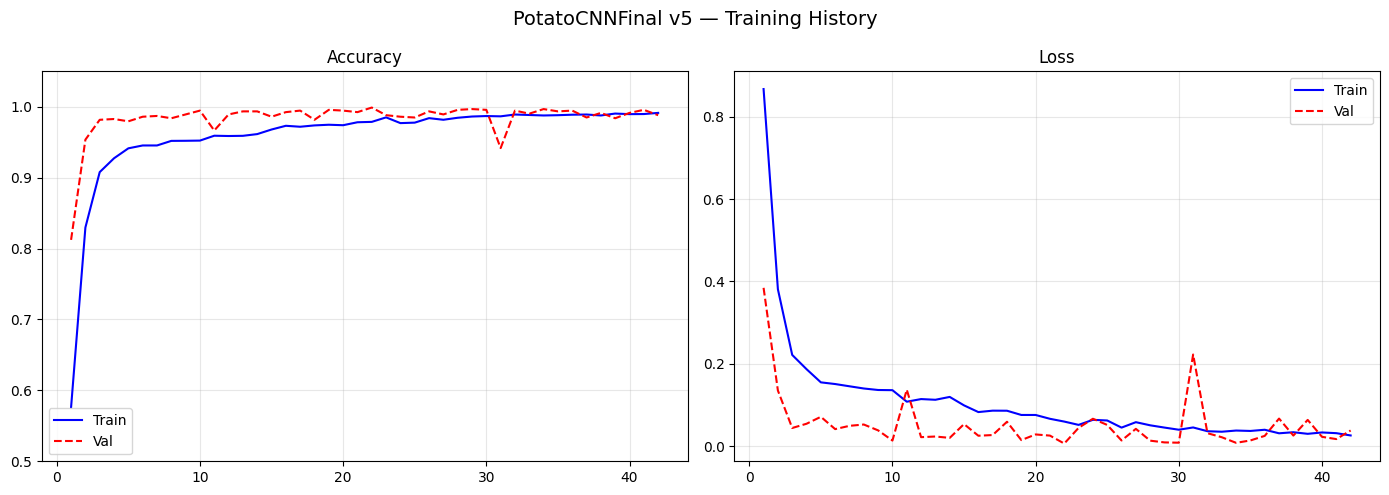

✅ Saved: training_v5.png


In [11]:
# ── CELL 10: Training Curves ──────────────────────────────────────────────────
ep = range(1, len(history['train_acc']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, history['train_acc'], 'b-',  label='Train')
axes[0].plot(ep, history['val_acc'],   'r--', label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.5, 1.05])
axes[1].plot(ep, history['train_loss'], 'b-',  label='Train')
axes[1].plot(ep, history['val_loss'],   'r--', label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('PotatoCNNFinal v5 — Training History', fontsize=14)
plt.tight_layout()
plt.savefig('training_v5.png', dpi=150)
plt.show()
print('✅ Saved: training_v5.png')

In [12]:
# ── CELL 11: Test Evaluation (Temperature Scaling + Mixed Precision) ──────────
#
# Temperature scaling: softmax(logits / T) instead of softmax(logits)
# T > 1 → spreads probability mass → less overconfident → more honest uncertainty
# Mixed precision: autocast uses float16 on GPU → faster, same accuracy

model.eval()
y_true, y_pred, y_conf = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        # ✅ #5 Mixed precision inference
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            out = model(inputs)
        # ✅ #2 Temperature scaling
        probs        = torch.softmax(out.float() / TEMPERATURE, dim=1)
        confs, preds = torch.max(probs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_conf.extend(confs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

test_acc = (y_true == y_pred).mean()
print(f'Test Accuracy   : {test_acc*100:.2f}%')
print(f'Mean Confidence : {y_conf.mean()*100:.2f}%  (expect lower than v3 due to T={TEMPERATURE})')
print(f'Min  Confidence : {y_conf.min()*100:.2f}%')
print(f'Max  Confidence : {y_conf.max()*100:.2f}%')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Test Accuracy   : 99.57%
Mean Confidence : 99.19%  (expect lower than v3 due to T=1.5)
Min  Confidence : 50.61%
Max  Confidence : 100.00%

                       precision    recall  f1-score   support

Potato___Early_blight       0.99      1.00      1.00       343
 Potato___Late_blight       1.00      0.99      0.99       343
     Potato___healthy       1.00      1.00      1.00       244

             accuracy                           1.00       930
            macro avg       1.00      1.00      1.00       930
         weighted avg       1.00      1.00      1.00       930



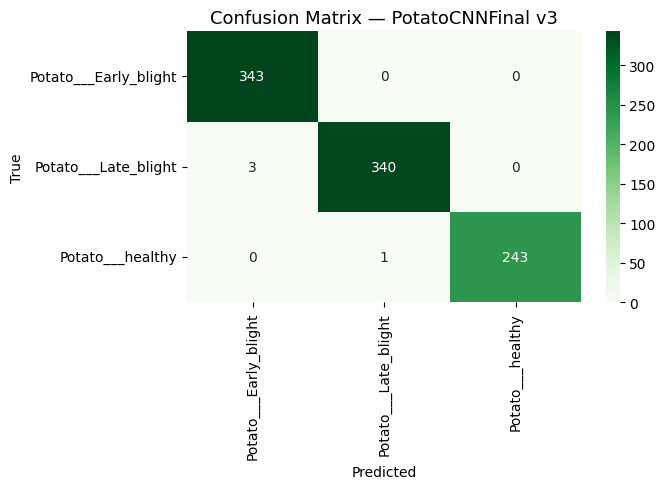

✅ Saved: confusion_v3.png


In [13]:
# ── CELL 12: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — PotatoCNNFinal v3', fontsize=13)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_v3.png', dpi=150)
plt.show()
print('✅ Saved: confusion_v3.png')

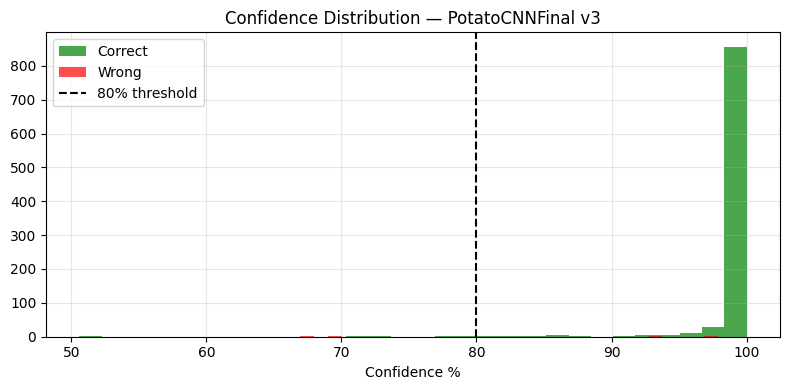

Predictions below 80% threshold: 10 / 930


In [14]:
# ── CELL 13: Confidence Distribution ──────────────────────────────────────────
correct = (y_pred == y_true)
plt.figure(figsize=(8, 4))
plt.hist(y_conf[correct]*100,  bins=30, alpha=0.7, color='green', label='Correct')
plt.hist(y_conf[~correct]*100, bins=30, alpha=0.7, color='red',   label='Wrong')
plt.axvline(CONFIDENCE_THRESHOLD*100, color='black', linestyle='--',
            label=f'{int(CONFIDENCE_THRESHOLD*100)}% threshold')
plt.title('Confidence Distribution — PotatoCNNFinal v3')
plt.xlabel('Confidence %')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_v3.png', dpi=150)
plt.show()
print(f'Predictions below {int(CONFIDENCE_THRESHOLD*100)}% threshold: '
      f'{(y_conf < CONFIDENCE_THRESHOLD).sum()} / {len(y_conf)}')

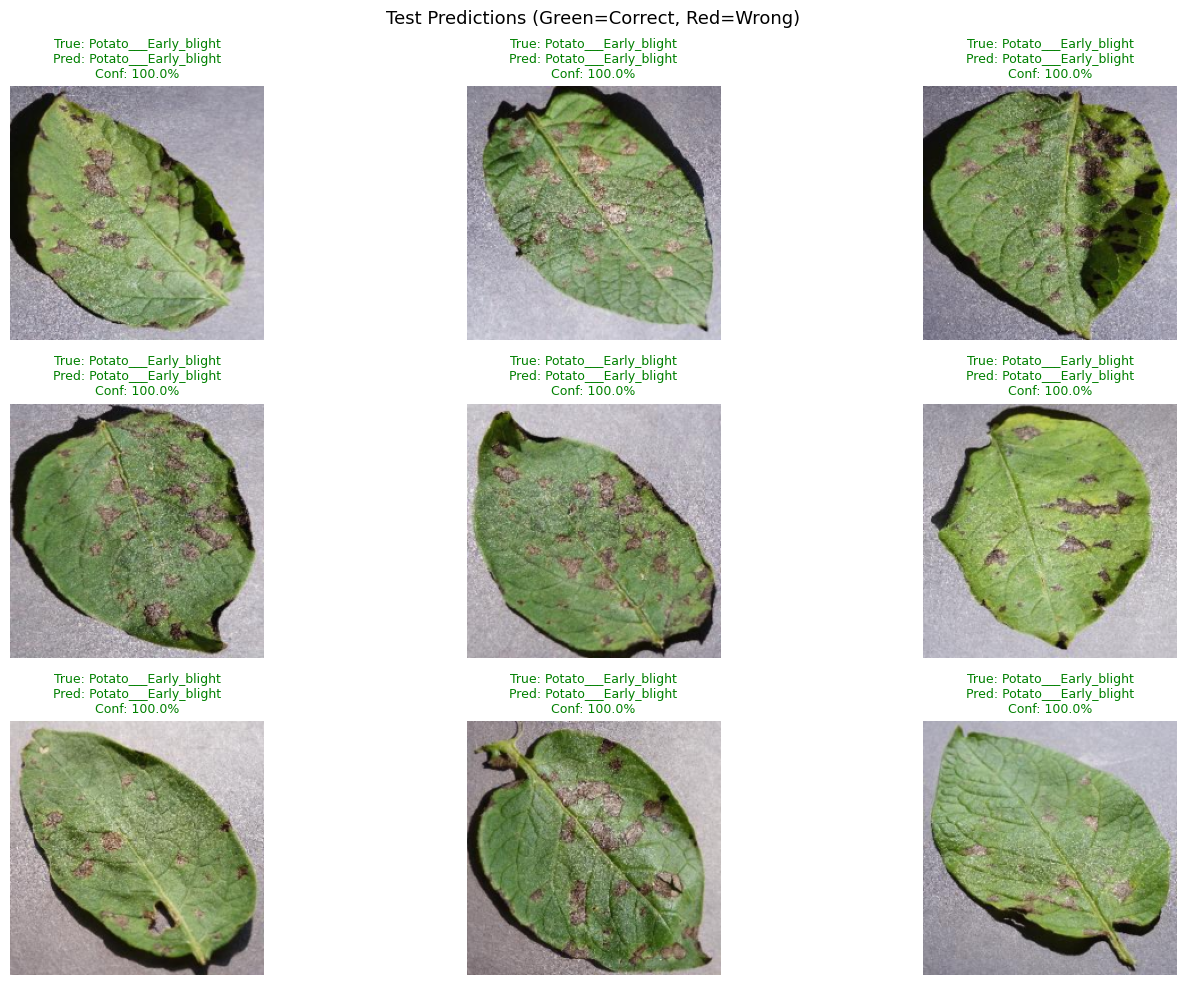

In [15]:
# ── CELL 14: Sample Predictions ───────────────────────────────────────────────
model.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    out   = model(images.to(DEVICE))
    probs = torch.softmax(out, dim=1)
    confs, preds = torch.max(probs, dim=1)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(15, 10))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i+1)
    img = images[i].numpy().transpose(1, 2, 0)
    img = np.clip(std * img + mean, 0, 1)
    plt.imshow(img)
    pred  = CLASS_NAMES[preds[i].item()]
    true  = CLASS_NAMES[labels[i].item()]
    conf  = confs[i].item()
    color = 'green' if pred == true else 'red'
    plt.title(f'True: {true}\nPred: {pred}\nConf: {conf*100:.1f}%', fontsize=9, color=color)
    plt.axis('off')
plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('predictions_v2.png', dpi=150)
plt.show()

In [21]:
# ── CELL 15: Save Model ────────────────────────────────────────────────────────
# optimal_threshold is set after running Cell 19 threshold analysis.
# If Cell 19 hasn't run yet, falls back to CONFIDENCE_THRESHOLD.
optimal_t = globals().get('best_t', CONFIDENCE_THRESHOLD)

save_path = os.path.join(MODEL_SAVE_PATH, 'potato_cnn_final_v5.pth')
torch.save({
    'model_state_dict'     : model.state_dict(),
    'class_names'          : CLASS_NAMES,
    'image_size'           : IMAGE_SIZE,
    'architecture'         : 'PotatoCNNFinal_v5',
    'confidence_threshold' : float(optimal_t),
    'temperature'          : TEMPERATURE,
    'test_accuracy'        : float(test_acc),
    'mean_confidence'      : float(y_conf.mean()),
}, save_path)
print(f'✅ Model saved  : {save_path}')
print(f'   Accuracy    : {test_acc*100:.2f}%')
print(f'   Mean Conf   : {y_conf.mean()*100:.2f}%')
print(f'   Threshold   : {float(optimal_t)*100:.0f}%')
print(f'   Temperature : {TEMPERATURE}')

✅ Model saved  : ./models_scratch\potato_cnn_final_v5.pth
   Accuracy    : 99.57%
   Mean Conf   : 99.19%
   Threshold   : 98%
   Temperature : 1.5


In [17]:
# ── CELL 16: Single Image Prediction (TTA + Temperature + Top-2) ─────────────
#
# TTA: runs 5 augmented passes and averages probabilities
# Temperature: scales logits before softmax for calibrated confidence
# Top-2: shows 2nd most likely class when model isn't fully certain
# Mixed precision: autocast for faster GPU inference

import torchvision.transforms.functional as TF

def get_tta_transforms(img):
    """Returns list of augmented PIL images for TTA."""
    return [
        img,                                             # original
        TF.hflip(img),                                   # horizontal flip
        TF.vflip(img),                                   # vertical flip
        TF.rotate(img, 90),                              # 90° rotation
        TF.center_crop(img, int(IMAGE_SIZE * 0.9)),      # center crop
    ]

def predict_image(image_path, threshold=None):
    # Load threshold from checkpoint if not provided
    if threshold is None:
        ckpt_path = os.path.join(MODEL_SAVE_PATH, 'potato_cnn_final.pth')
        if os.path.exists(ckpt_path):
            ckpt      = torch.load(ckpt_path, map_location=DEVICE)
            threshold = ckpt.get('confidence_threshold', CONFIDENCE_THRESHOLD)
            temp      = ckpt.get('temperature', TEMPERATURE)
        else:
            threshold = CONFIDENCE_THRESHOLD
            temp      = TEMPERATURE
    else:
        temp = TEMPERATURE

    model.eval()
    img = Image.open(image_path).convert('RGB')

    # ✅ #3 TTA — 5 augmented passes
    tta_imgs  = get_tta_transforms(img)
    all_probs = []
    with torch.no_grad():
        for aug_img in tta_imgs:
            # Resize crop augments may change size — eval_transform handles resize
            tensor = eval_transform(aug_img).unsqueeze(0).to(DEVICE)
            # ✅ #5 Mixed precision
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                out = model(tensor)
            # ✅ #2 Temperature scaling
            probs = torch.softmax(out.float() / temp, dim=1)[0]
            all_probs.append(probs)

    # Average across TTA passes
    avg_probs = torch.stack(all_probs).mean(dim=0)
    confidence, pred_idx = torch.max(avg_probs, dim=0)
    confidence = confidence.item()

    # ✅ #7 Top-2 predictions
    top2_vals, top2_idxs = torch.topk(avg_probs, 2)

    pred = CLASS_NAMES[pred_idx.item()] if confidence >= threshold else 'Uncertain'

    # ── Display ──
    plt.figure(figsize=(5, 4))
    plt.imshow(img); plt.axis('off')
    title_color = 'green' if confidence >= threshold else 'red'
    plt.title(f'{pred}\n{confidence*100:.1f}% (T={temp})', color=title_color)
    plt.tight_layout()
    plt.show()

    print(f'Prediction  : {pred}')
    print(f'Confidence  : {confidence*100:.2f}%')
    print(f'Threshold   : {threshold*100:.0f}%')
    print(f'Temperature : {temp}')
    print(f'TTA passes  : {len(tta_imgs)}')
    print()
    print('Top-2 predictions:')
    for rank, (v, i) in enumerate(zip(top2_vals, top2_idxs), 1):
        print(f'  #{rank}: {CLASS_NAMES[i.item()]:30s} {v.item()*100:.2f}%')
    print()
    print('All class probabilities:')
    for n, p in zip(CLASS_NAMES, avg_probs):
        print(f'  {n:30s} {p.item()*100:.2f}%')

# ⚠️ Uncomment to test:
# predict_image('path/to/leaf.jpg')
print('✅ predict_image() ready! (TTA + Temperature + Top-2 + Mixed Precision)')
print(f'   Temperature : {TEMPERATURE}  |  TTA passes: {TTA_STEPS}  |  Threshold: {CONFIDENCE_THRESHOLD}')

✅ predict_image() ready! (TTA + Temperature + Top-2 + Mixed Precision)
   Temperature : 1.5  |  TTA passes: 5  |  Threshold: 0.8


In [18]:
# ── CELL 17: Split Verification ───────────────────────────────────────────────
from collections import Counter
print('Split verification (per class):')
for split_name, slist in [('Train', train_samples), ('Val', val_samples), ('Test', test_samples)]:
    c = Counter(l for _, l in slist)
    print(f'  {split_name}: ' + ', '.join(f'{CLASS_NAMES[k]}: {c[k]}' for k in sorted(c)))

Split verification (per class):
  Train: Potato___Early_blight: 2739, Potato___Late_blight: 2739, Potato___healthy: 1945
  Val: Potato___Early_blight: 342, Potato___Late_blight: 342, Potato___healthy: 243
  Test: Potato___Early_blight: 343, Potato___Late_blight: 343, Potato___healthy: 244


In [19]:
# ── CELL 18: FastAPI Inference Note ──────────────────────────────────────────
# ⚠️ If you use this model in your FastAPI backend, update the threshold there too:
#
#   CONFIDENCE_THRESHOLD = 0.80   # was 0.70
#
# The threshold is also saved in potato_cnn_final.pth under 'confidence_threshold'
# so you can load it at runtime:
#
#   ckpt = torch.load('potato_cnn_final.pth')
#   threshold = ckpt.get('confidence_threshold', 0.80)
print('✅ Remember to update FastAPI backend threshold to 0.80!')
print(f'   Saved in .pth: confidence_threshold = {CONFIDENCE_THRESHOLD}')

✅ Remember to update FastAPI backend threshold to 0.80!
   Saved in .pth: confidence_threshold = 0.8


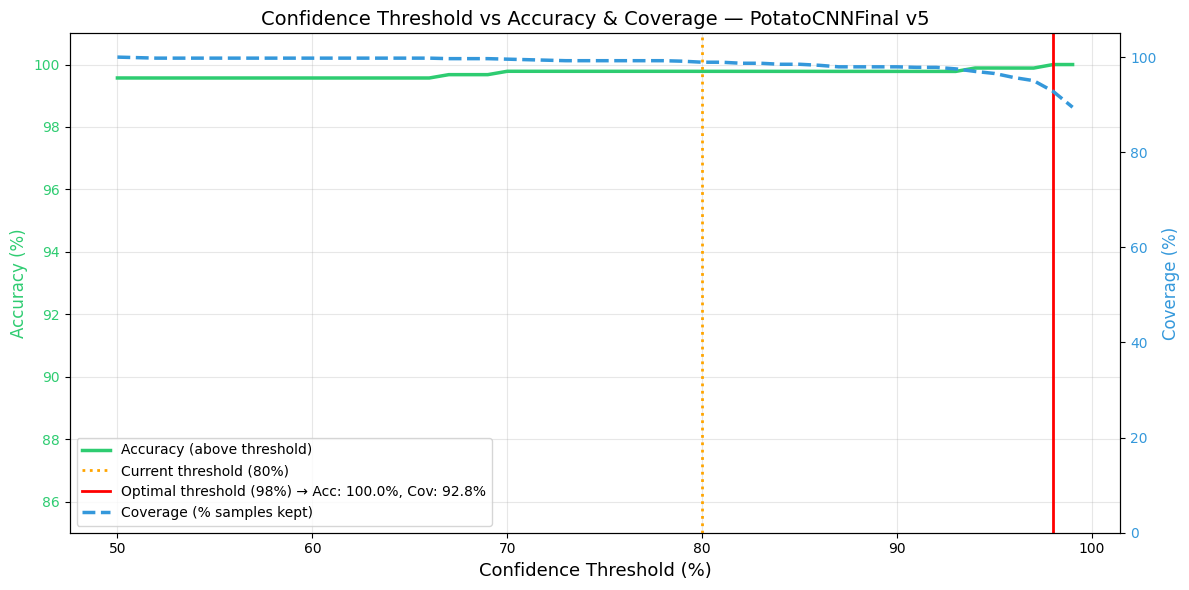


📊 Threshold Analysis:
   Current  threshold : 80%  → Acc: 99.78%, Coverage: 98.9%
   Optimal  threshold : 98%  → Acc: 100.00%, Coverage: 92.8%

   Threshold Table (every 5%):
    Threshold   Accuracy   Coverage
   --------------------------------
          50%     99.57%     100.0%
          55%     99.57%      99.8%
          60%     99.57%      99.8%
          65%     99.57%      99.8%
          70%     99.78%      99.6%
          75%     99.78%      99.2%
          80%     99.78%      98.9% ← current
          85%     99.78%      98.5%
          90%     99.78%      98.0%
          95%     99.89%      96.6%

✅ Saved: threshold_analysis_v5.png


In [20]:
# ── CELL 19: Confidence Threshold vs Accuracy & Coverage ──────────────────────
#
# This graph helps find the BEST threshold value:
#   - Accuracy  = among predictions ABOVE threshold, what % are correct?
#   - Coverage  = what % of test samples are ABOVE threshold (not 'Uncertain')?
#   - The sweet spot is where accuracy is high AND coverage is still acceptable
#
# Run AFTER Cell 11 (test evaluation) so y_conf and y_true/y_pred are available

thresholds = np.arange(0.50, 1.00, 0.01)

accuracies = []
coverages  = []

for t in thresholds:
    mask     = y_conf >= t
    coverage = mask.sum() / len(y_conf)           # % of samples above threshold
    if mask.sum() == 0:
        acc = 0.0
    else:
        acc = (y_pred[mask] == y_true[mask]).mean()  # accuracy on those samples
    accuracies.append(acc * 100)
    coverages.append(coverage * 100)

accuracies = np.array(accuracies)
coverages  = np.array(coverages)

# ── Find optimal threshold: highest accuracy where coverage >= 80% ──
valid_mask   = coverages >= 80.0
if valid_mask.any():
    best_idx   = np.argmax(accuracies * valid_mask)  # best acc with >= 80% coverage
    best_t     = thresholds[best_idx]
    best_acc   = accuracies[best_idx]
    best_cov   = coverages[best_idx]
else:
    best_idx   = np.argmax(accuracies)
    best_t     = thresholds[best_idx]
    best_acc   = accuracies[best_idx]
    best_cov   = coverages[best_idx]

# ── Plot ──
fig, ax1 = plt.subplots(figsize=(12, 6))

color_acc = '#2ecc71'
color_cov = '#3498db'

ax1.plot(thresholds * 100, accuracies, color=color_acc, lw=2.5, label='Accuracy (above threshold)')
ax1.set_xlabel('Confidence Threshold (%)', fontsize=13)
ax1.set_ylabel('Accuracy (%)', color=color_acc, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_ylim([85, 101])
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(thresholds * 100, coverages, color=color_cov, lw=2.5,
         linestyle='--', label='Coverage (% samples kept)')
ax2.set_ylabel('Coverage (%)', color=color_cov, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_cov)
ax2.set_ylim([0, 105])

# Mark current threshold (0.80)
ax1.axvline(80, color='orange', linestyle=':', lw=2, label='Current threshold (80%)')

# Mark optimal threshold
ax1.axvline(best_t * 100, color='red', linestyle='-', lw=2,
            label=f'Optimal threshold ({best_t*100:.0f}%) → Acc: {best_acc:.1f}%, Cov: {best_cov:.1f}%')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

plt.title('Confidence Threshold vs Accuracy & Coverage — PotatoCNNFinal v5', fontsize=14)
plt.tight_layout()
plt.savefig('threshold_analysis_v5.png', dpi=150)
plt.show()

print(f'\n📊 Threshold Analysis:')
print(f'   Current  threshold : 80%  → Acc: {accuracies[np.argmin(np.abs(thresholds-0.80))]:.2f}%,'
      f' Coverage: {coverages[np.argmin(np.abs(thresholds-0.80))]:.1f}%')
print(f'   Optimal  threshold : {best_t*100:.0f}%  → Acc: {best_acc:.2f}%, Coverage: {best_cov:.1f}%')
print(f'\n   Threshold Table (every 5%):')
print(f'   {"Threshold":>10} {"Accuracy":>10} {"Coverage":>10}')
print(f'   {"-"*32}')
for t, a, c in zip(thresholds, accuracies, coverages):
    if abs(t * 100 % 5) < 0.6:   # print every 5%
        marker = ' ← current' if abs(t - 0.80) < 0.006 else ''
        marker = ' ← optimal' if abs(t - best_t) < 0.006 else marker
        print(f'   {t*100:>9.0f}% {a:>9.2f}% {c:>9.1f}%{marker}')
print(f'\n✅ Saved: threshold_analysis_v5.png')